In [1]:
!pip install missingno
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [2]:
train_df = pd.read_csv(r'C:\Users\Alperen\Desktop\datahon26\train.csv')
test_df = pd.read_csv(r'C:\Users\Alperen\Desktop\datahon26\test_x.csv')

print("--- Veri Seti Boyutları ---")
print(f"Eğitim Seti (Train) Boyutu: {train_df.shape}")
print(f"Test Seti (Test) Boyutu: {test_df.shape}\n")

pd.set_option('display.max_columns', None)
display(train_df.head(60))


--- Veri Seti Boyutları ---
Eğitim Seti (Train) Boyutu: (10000, 47)
Test Seti (Test) Boyutu: (10000, 46)



,student_id,application_year,age,graduation_year,department,university_tier,cgpa,english_exam_score,attendance_rate,failed_courses_count,target_role,coding_score,problem_solving_score,data_structures_score,sql_score,machine_learning_score,backend_score,frontend_score,cloud_score,devops_score,project_quality_score,real_client_project_count,internship_count,internship_duration_months,freelance_project_count,hackathon_count,hackathon_awards,portfolio_score,github_repo_count,github_avg_stars,open_source_contribution_count,linkedin_profile_score,cv_quality_score,technical_interview_score,hr_interview_score,communication_score,teamwork_score,leadership_score,presentation_score,certification_count,bootcamp_count,applications_sent,interviews_attended,hobby,preferred_social_media_platform,career_success_score,mentor_feedback_text
0,STU_000001,2021,21,2021,Computer Engineering,Tier 4,3.17,62.54,77.31,0,DevOps Engineer,73.28,71.11,52.91,84.980000,81.770000,62.710000,71.570000,63.041897,69.952625,81.90,0,3,11.0,0,0,0,65.54,18,1.85,10.0,86.58,42.06,40.57,50.29,79.83,44.14,62.70,58.84,3,1,24,0,photography,LinkedIn,86.78,Proje kalitesi ve makine öğrenimi konusundaki ...
1,STU_000002,2024,20,2024,Computer Engineering,Tier 4,3.24,75.10,87.13,3,Backend Developer,63.12,78.90,61.81,37.450740,65.540000,69.944694,60.830000,64.510000,57.940000,24.68,0,0,NaN,1,1,0,54.48,7,1.22,1.0,33.34,65.39,82.99,67.43,43.60,22.05,42.32,40.54,2,0,46,5,reading,YouTube,46.16,Kodlama ve problem çözme becerileri gelişmekte...
2,STU_000003,2024,28,2024,Electrical Electronics Engineering,Tier 4,3.00,68.53,95.64,1,Frontend Developer,100.00,86.44,83.62,85.440000,87.180000,80.580000,96.433149,62.220000,81.750000,78.92,2,0,0.0,2,0,0,75.10,4,12.12,2.0,61.37,52.25,43.06,20.19,48.62,65.64,47.27,82.56,1,2,46,5,cinema,Reddit,84.08,İleri düzey frontend geliştirme becerileri ile...
3,STU_000004,2019,22,2018,Computer Engineering,Tier 1,2.82,54.85,77.80,2,Backend Developer,99.08,72.15,77.15,89.214871,69.490000,85.751415,72.860000,73.680000,54.080000,54.93,0,1,9.0,0,1,0,82.40,4,2.96,3.0,45.15,24.12,32.06,28.00,59.84,3.89,78.69,85.05,2,4,49,7,running,Reddit,89.97,Güçlü bir kodlama yeteneği ve backend geliştir...
4,STU_000005,2026,22,2026,Computer Engineering,Tier 3,2.28,72.25,71.97,1,Product Analyst,92.65,91.15,84.51,70.700000,74.110000,80.620000,86.830000,80.340000,87.560000,72.85,2,0,NaN,2,0,0,48.02,14,0.97,12.0,74.86,74.83,71.82,65.14,63.30,52.86,27.22,84.29,1,0,119,13,football,X,92.46,Ürün analizi alanına olan tutkusu ve makine öğ...
5,STU_000006,2022,26,2022,Management Information Systems,Tier 2,3.72,94.87,81.44,2,AI Engineer,64.29,62.56,47.80,51.630000,50.078712,55.700000,63.860000,43.390000,55.800000,70.19,1,2,8.0,0,2,0,49.59,6,4.14,2.0,67.97,71.30,21.76,66.82,62.88,29.28,47.17,39.38,2,1,53,7,reading,Reddit,68.87,"Bu öğrenci, eğitim süresince projelerde göster..."
6,STU_000007,2023,22,2023,Software Engineering,Tier 2,2.67,71.64,81.34,1,Backend Developer,53.15,58.43,67.95,61.008289,64.410000,52.735524,62.660000,67.860000,31.650000,64.11,0,1,6.0,3,0,0,63.66,17,4.64,10.0,87.70,62.79,84.37,43.16,35.47,33.26,29.55,52.21,1,2,127,18,music,Instagram,78.96,Projelerindeki özgün yaklaşım ve yazılım geliş...
7,STU_000008,2024,24,2024,Electrical Electronics Engineering,Tier 3,3.66,48.14,89.81,2,DevOps Engineer,99.56,90.56,91.65,100.000000,85.600000,100.000000,70.960000,100.000000,97.407629,36.10,0,2,5.0,1,1,0,58.96,4,2.26,0.0,89.86,97.57,56.81,64.02,71.33,62.42,48.02,70.04,4,1,51,8,photography,TikTok,77.43,Mükemmel teknik becerileri ve geniş bilgi biri...
8,STU_000009,2023,25,2023,Computer Engineering,Tier 4,2.23,40.47,83.14,1,Backend Developer,76.12,58.96,59.22,83.823381,70.890000,73.808476,70.520000,70.480000,61.490000,19.44,0,0,NaN,0,3,1,40.86,3,0.96,2.0,NaN,44.51,87.52,78.90,91.79,86.72,35.33,84.59,3,0,62,10,photography,Instagram,70.15,Hackathonlardaki başarıları ve iletişim beceri...
9,STU_000010,2019,22,2019,Software Engineering,Tier 3,3.57,25.87,96.14,2,Data Analyst,36.64,61.20,49.06,

Train Eksik Degerler


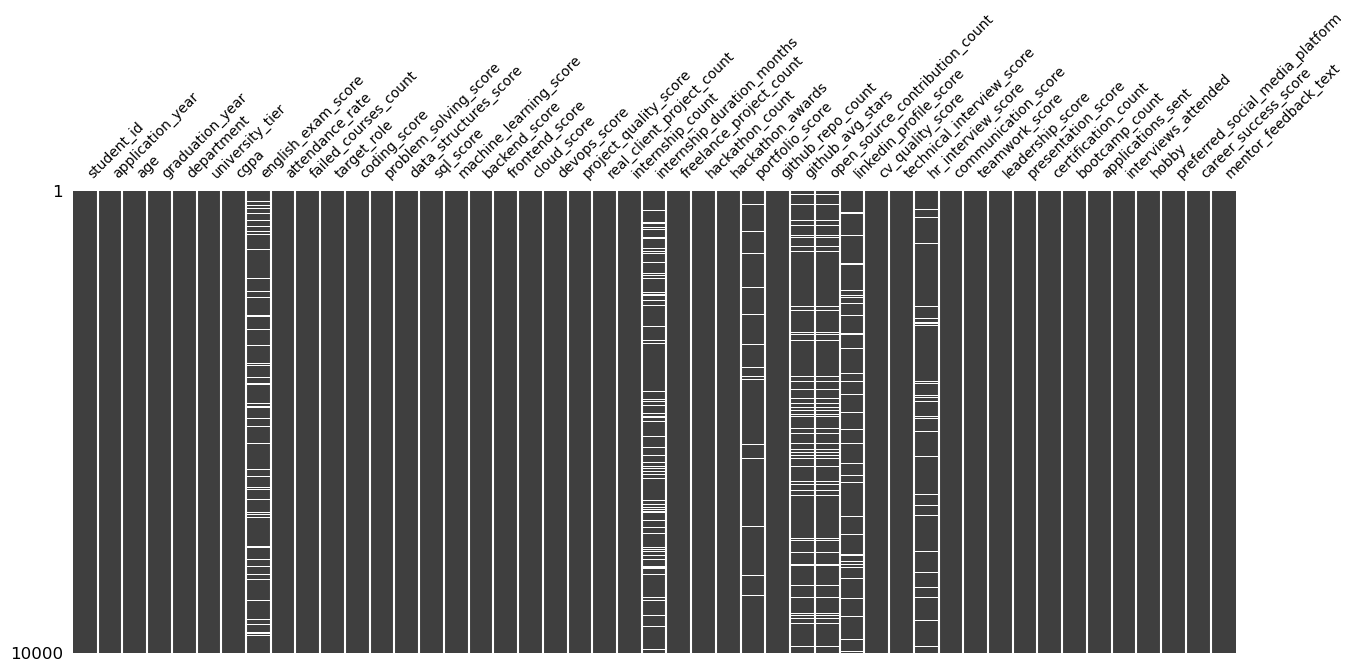

Test Eksik Degerler


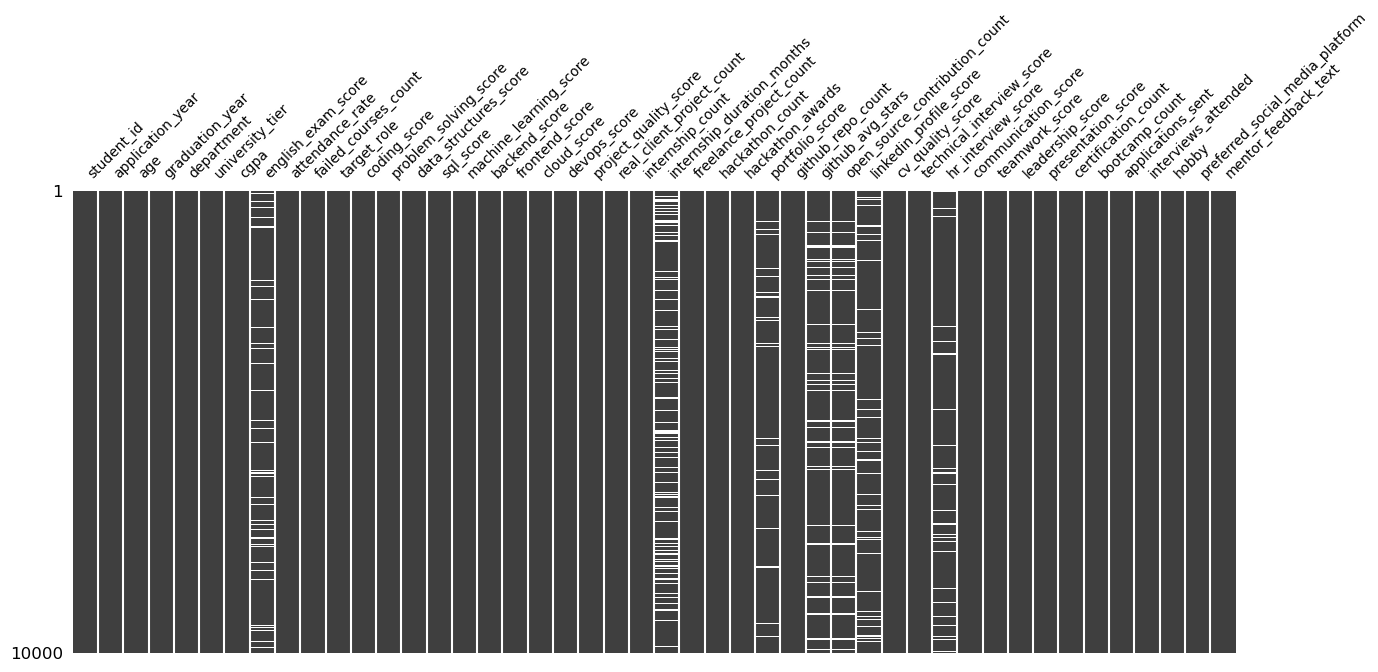

In [3]:
print("Train Eksik Degerler")
msno.matrix(train_df, figsize=(15, 6), sparkline=False, fontsize=10)
plt.show()

print("Test Eksik Degerler")
msno.matrix(test_df, figsize=(15, 6), sparkline=False, fontsize=10)
plt.show()

In [6]:
# 1. KATEGORİK İLİŞKİ KONTROLÜ
print("--- HEDEF ROLE GÖRE İNGİLİZCE SKORU MEDYANLARI ---")
print(train_df.groupby('target_role')['english_exam_score'].median().sort_values(ascending=False))

print("\n--- ÜNİVERSİTE SEVİYESİNE GÖRE İNGİLİZCE SKORU MEDYANLARI ---")
print(train_df.groupby('university_tier')['english_exam_score'].median().sort_values(ascending=False))


# 2. MANTIKSAL/YAPISAL EKSİKLİK KONTROLÜ
# İngilizce notu eksik olan kişilerin HR mülakat skoru durumuna bakalım
ingilizce_eksik = train_df[train_df['english_exam_score'].isnull()]
print(f"\n--- İNGİLİZCE SKORU EKSİK OLAN {len(ingilizce_eksik)} KİŞİNİN DURUMU ---")
print("Bu kişilerin HR Interview Skoru eksik olanların sayısı:")
print(ingilizce_eksik['hr_interview_score'].isnull().sum())

--- HEDEF ROLE GÖRE İNGİLİZCE SKORU MEDYANLARI ---
target_role
Cloud Engineer           59.015000
DevOps Engineer          58.940000
Cybersecurity Analyst    58.530000
Backend Developer        58.270000
Product Analyst          58.260000
Data Scientist           58.160000
Software Developer       58.005000
Data Analyst             57.931649
Frontend Developer       57.089839
AI Engineer              56.980000
MLOps Engineer           56.800000
Name: english_exam_score, dtype: float64

--- ÜNİVERSİTE SEVİYESİNE GÖRE İNGİLİZCE SKORU MEDYANLARI ---
university_tier
Tier 4    58.420000
Tier 2    58.162329
Tier 3    57.900000
Tier 1    57.690000
Name: english_exam_score, dtype: float64

--- İNGİLİZCE SKORU EKSİK OLAN 0 KİŞİNİN DURUMU ---
Bu kişilerin HR Interview Skoru eksik olanların sayısı:
0


In [7]:
print("--- GITHUB VERİLERİ KONTROLÜ ---")
github_eksikler = train_df[train_df['github_avg_stars'].isnull() & train_df['open_source_contribution_count'].isnull()]
print(f"Her iki GitHub verisi de AYNI ANDA eksik olan satır sayısı: {len(github_eksikler)}")

repo_sifir_olanlar = train_df[train_df['github_repo_count'] == 0]
print(f"Github Repo sayısı 0 olan toplam satır: {len(repo_sifir_olanlar)}")
print("Repo sayısı 0 olanların ilk 5 satırındaki eksiklik durumları:")
display(repo_sifir_olanlar[['github_repo_count', 'github_avg_stars', 'open_source_contribution_count']].head())

print("\n" + "="*50 + "\n")

print("--- STAJ VERİLERİ KONTROLÜ ---")
staj_sifir_olanlar = train_df[train_df['internship_count'] == 0]
print(f"Hiç staj yapmamış (internship_count = 0) öğrenci sayısı: {len(staj_sifir_olanlar)}")

staj_supheli = train_df[(train_df['internship_count'] > 0) & (train_df['internship_duration_months'].isnull())]
print(f"Staj YAPMIŞ ama staj SÜRESİ EKSİK olan öğrenci sayısı: {len(staj_supheli)}")

if len(staj_supheli) > 0:
    print("Bu şüpheli öğrencilerin bazıları:")
    display(staj_supheli[['internship_count', 'internship_duration_months']].head())

--- GITHUB VERİLERİ KONTROLÜ ---
Her iki GitHub verisi de AYNI ANDA eksik olan satır sayısı: 0
Github Repo sayısı 0 olan toplam satır: 82
Repo sayısı 0 olanların ilk 5 satırındaki eksiklik durumları:


,github_repo_count,github_avg_stars,open_source_contribution_count
9,0.0,2.477063,1.202598
21,0.0,4.522829,1.000290
175,0.0,1.540000,2.000000
341,0.0,3.030716,2.391352
485,0.0,1.890000,2.000000




--- STAJ VERİLERİ KONTROLÜ ---
Hiç staj yapmamış (internship_count = 0) öğrenci sayısı: 3070
Staj YAPMIŞ ama staj SÜRESİ EKSİK olan öğrenci sayısı: 0


In [8]:
# 1. Train setinde internship_count değeri 0 olanların NaN staj sürelerini 0 yap
train_df.loc[(train_df['internship_count'] == 0) & (train_df['internship_duration_months'].isnull()), 'internship_duration_months'] = 0

# 2. Test setinde internship_count değeri 0 olanların NaN staj sürelerini 0 yap
test_df.loc[(test_df['internship_count'] == 0) & (test_df['internship_duration_months'].isnull()), 'internship_duration_months'] = 0

# 3. Kalan eksiklikleri kontrol edelim
print("--- STAJ SÜRESİ (internship_duration_months) EKSİK VERİ DURUMU ---")
print(f"Train Seti Kalan Eksik: {train_df['internship_duration_months'].isnull().sum()}")
print(f"Test Seti Kalan Eksik: {test_df['internship_duration_months'].isnull().sum()}")

--- STAJ SÜRESİ (internship_duration_months) EKSİK VERİ DURUMU ---
Train Seti Kalan Eksik: 0
Test Seti Kalan Eksik: 0


In [9]:
# 1. Sadece staj YAPMIŞ olan (internship_count > 0) öğrencileri filtreleyelim
# (Çünkü 0-0 ilişkisi diğer tüm gerçek korelasyonları ezer/gizler)
staj_yapanlar = train_df[train_df['internship_count'] > 0]

# 2. Sadece sayısal sütunları seçelim
sayisal_staj_yapanlar = staj_yapanlar.select_dtypes(include=['int64', 'float64'])

# 3. internship_count sütununu korelasyon hesabından çıkaralım
korelasyon_sonuclari = sayisal_staj_yapanlar.drop(columns=['internship_count']).corr()['internship_duration_months'].sort_values(ascending=False)

# 4. Gerçek ve temiz ilişkileri görelim
print("--- Staj Yapan Öğrencilerde Staj SÜRESİ ile En Yüksek Korelasyonlar ---")
print(korelasyon_sonuclari.head(10)) # Kendisi (1.0) ve en yüksek 9 değişken

print("\n--- En Düşük / Negatif Korelasyonlar ---")
print(korelasyon_sonuclari.tail(5))

--- Staj Yapan Öğrencilerde Staj SÜRESİ ile En Yüksek Korelasyonlar ---
internship_duration_months    1.000000
career_success_score          0.040653
coding_score                  0.022670
graduation_year               0.015487
devops_score                  0.014510
application_year              0.014300
sql_score                     0.011142
leadership_score              0.009755
english_exam_score            0.009665
data_structures_score         0.008800
Name: internship_duration_months, dtype: float64

--- En Düşük / Negatif Korelasyonlar ---
interviews_attended         -0.010877
technical_interview_score   -0.011417
linkedin_profile_score      -0.013820
teamwork_score              -0.015211
cv_quality_score            -0.039112
Name: internship_duration_months, dtype: float64


In [10]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# 1. En mantıklı/yüksek korelasyon veren sütunları ve dolduracağımız sütunu seçiyoruz
secili_sutunlar = ['coding_score', 'age', 'real_client_project_count', 
                   'hackathon_awards', 'backend_score', 'internship_duration_months']

# 2. Imputer'ı tanımlıyoruz
imputer = IterativeImputer(max_iter=10, random_state=42)

# 3. Train Seti: Öğren, Doldur ve Çıkan Sonuçları YUVARLA
train_imputed = imputer.fit_transform(train_df[secili_sutunlar])
# internship_duration_months listemizin en sonuncu (index -1) sütunu olduğu için onu alıp yuvarlıyoruz
train_df['internship_duration_months'] = np.round(train_imputed[:, -1]) 

# 4. Test Seti: Train'den öğrenilenle Doldur ve YUVARLA
test_imputed = imputer.transform(test_df[secili_sutunlar])
test_df['internship_duration_months'] = np.round(test_imputed[:, -1])

# 5. Sonuç Kontrolü
print("--- STAJ SÜRESİ EKSİK KONTROLÜ ---")
print(f"Train Seti Kalan Eksik: {train_df['internship_duration_months'].isnull().sum()}")
print("Train Seti İlk 5 Staj Süresi (Format Kontrolü):")
print(train_df['internship_duration_months'].head()) 


--- STAJ SÜRESİ EKSİK KONTROLÜ ---
Train Seti Kalan Eksik: 0
Train Seti İlk 5 Staj Süresi (Format Kontrolü):
0    11.0
1     5.0
2     0.0
3     9.0
4     4.0
Name: internship_duration_months, dtype: float64


In [11]:
# Sadece staj yapanları filtrele (0'ların medyanı aşağı çekmesini engellemek için)
staj_yapanlar = train_df[train_df['internship_count'] > 0]

# İnceleyeceğimiz kategorik sütunlar
aday_kategoriler = ['department', 'university_tier', 'target_role']

for kategori in aday_kategoriler:
    print(f"\n--- {kategori.upper()} BAZLI STAJ SÜRESİ (AY) ---")
    grup_ozet = staj_yapanlar.groupby(kategori)['internship_duration_months'].agg(['median', 'count'])
    print(grup_ozet.sort_values(by='median', ascending=False))


--- DEPARTMENT BAZLI STAJ SÜRESİ (AY) ---
                                    median  count
department                                       
Computer Engineering                   8.0   2040
Management Information Systems         8.0    552
Mathematics                            8.0    418
Electrical Electronics Engineering     7.0   1264
Industrial Engineering                 7.0    537
Software Engineering                   7.0   1578
Statistics                             7.0    541

--- UNIVERSITY_TIER BAZLI STAJ SÜRESİ (AY) ---
                 median  count
university_tier               
Tier 1              8.0   1291
Tier 2              8.0   2212
Tier 4              8.0   1116
Tier 3              7.0   2311

--- TARGET_ROLE BAZLI STAJ SÜRESİ (AY) ---
                       median  count
target_role                         
Backend Developer         8.0   1260
Data Analyst              8.0    799
Data Scientist            8.0    866
DevOps Engineer           8.0    385
Fronten

In [12]:
# 1. Sadece staj yapanların genel medyanını TRAIN setinden öğren
genel_medyan = train_df[train_df['internship_count'] > 0]['internship_duration_months'].median()
print(f"Staj yapanlar için Genel Medyan: {genel_medyan} ay")

# 2. Train ve Test setindeki eksik staj sürelerini bu genel medyan ile doldur
train_df['internship_duration_months'] = train_df['internship_duration_months'].fillna(genel_medyan)
test_df['internship_duration_months'] = test_df['internship_duration_months'].fillna(genel_medyan)

# 3. Kalan eksiklikleri kontrol et
print("--- STAJ SÜRESİ EKSİK KONTROLÜ ---")
print(f"Train Seti Kalan Eksik: {train_df['internship_duration_months'].isnull().sum()}")
print(f"Test Seti Kalan Eksik: {test_df['internship_duration_months'].isnull().sum()}")

Staj yapanlar için Genel Medyan: 8.0 ay
--- STAJ SÜRESİ EKSİK KONTROLÜ ---
Train Seti Kalan Eksik: 0
Test Seti Kalan Eksik: 0


In [13]:
from sklearn.impute import KNNImputer

# 1. Hedeflediğimiz doldurulacak sütunlar
doldurulacak_sutunlar = ['hr_interview_score', 'portfolio_score', 'linkedin_profile_score']

# 2. KNN'in mesafe ölçümü için kullanacağı tüm sayısal sütunları belirliyoruz
# İngilizce skorunu ve (sızıntı olmaması için) target değişkenini dışarıda bırakıyoruz
sayisal_sutunlar = train_df.select_dtypes(include=['int64', 'float64']).columns
haric_tutulacaklar = ['career_success_score', 'english_exam_score']

# KNN'e sokulacak nihai sütun listesi
knn_sutunlari = [col for col in sayisal_sutunlar if col not in haric_tutulacaklar]

# 3. KNN Imputer modelini tanımlıyoruz (K=5)
imputer = KNNImputer(n_neighbors=5)

# Train setinden öğren ve Train setindeki eksikleri doldur
train_df[knn_sutunlari] = imputer.fit_transform(train_df[knn_sutunlari])

# Train'den öğrendiklerinle Test setindeki eksikleri doldur
test_df[knn_sutunlari] = imputer.transform(test_df[knn_sutunlari])

# 4. Sonuçları kontrol edelim
print("--- KNN İMPUTASYONU SONRASI KALAN EKSİKLER ---")
print("Train Seti:")
print(train_df[doldurulacak_sutunlar].isnull().sum())
print("\nTest Seti:")
print(test_df[doldurulacak_sutunlar].isnull().sum())

--- KNN İMPUTASYONU SONRASI KALAN EKSİKLER ---
Train Seti:
hr_interview_score        0
portfolio_score           0
linkedin_profile_score    0
dtype: int64

Test Seti:
hr_interview_score        0
portfolio_score           0
linkedin_profile_score    0
dtype: int64


In [15]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

# 1. Mesafe ölçümünde kullanılacak sütunları belirliyoruz (Hedef değişken sızıntı yapmasın diye hariç tutuluyor)
sayisal_sutunlar = train_df.select_dtypes(include=['int64', 'float64']).columns
knn_sutunlari = [col for col in sayisal_sutunlar if col != 'career_success_score']

# 2. Scaler ve Imputer nesnelerini tanımlıyoruz
scaler = MinMaxScaler()
imputer = KNNImputer(n_neighbors=5, weights='distance')

# 3. Train Seti: Ölçekle, Doldur, Geri Döndür
train_scaled = scaler.fit_transform(train_df[knn_sutunlari])
train_imputed = imputer.fit_transform(train_scaled)
train_df[knn_sutunlari] = scaler.inverse_transform(train_imputed)

# 4. Test Seti: Train'den öğrenilen ölçekle sıkıştır, Doldur, Geri Döndür
test_scaled = scaler.transform(test_df[knn_sutunlari])
test_imputed = imputer.transform(test_scaled)
test_df[knn_sutunlari] = scaler.inverse_transform(test_imputed)

# 5. Kontrol
print("\n--- İNGİLİZCE SKORU EKSİK VERİ KONTROLÜ ---")
print("Train Seti Kalan Eksik:", train_df['english_exam_score'].isnull().sum())
print("Test Seti Kalan Eksik:", test_df['english_exam_score'].isnull().sum())


--- İNGİLİZCE SKORU EKSİK VERİ KONTROLÜ ---
Train Seti Kalan Eksik: 0
Test Seti Kalan Eksik: 0


In [18]:
import re
import pandas as pd

#Mentor Notları

def metin_temizle(text):
    # Eğer hücre boşsa (NaN) boş string döndür
    if pd.isnull(text):
        return ""
    
    # 1. Küçük harfe çevir (Büyük i ve küçük ı harfi sorununu çözmek için Türkçe karakterleri manuel değiştirebiliriz ama temel olarak lower yeterlidir)
    text = text.lower()
    
    # 2. Noktalama işaretlerini kaldır (Sadece harfler ve boşluklar kalsın)
    text = re.sub(r'[^\w\s]', '', text)
    
    # 3. Rakamları kaldır (Mentor notlarındaki yaş veya tarih gibi rakamlar genelde duygu/başarı belirtmez)
    text = re.sub(r'\d+', '', text)
    
    # 4. Fazladan boşlukları (çift boşluk, tab vb.) tek boşluğa indir
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    
    return text

# Orijinal sütunu bozmamak için temizlenmiş hallerini yeni bir sütuna yazıyoruz
train_df['clean_mentor_notes'] = train_df['mentor_feedback_text'].apply(metin_temizle)
test_df['clean_mentor_notes'] = test_df['mentor_feedback_text'].apply(metin_temizle)

# Sonucu kontrol edelim (Orijinal vs Temizlenmiş)
print(train_df[['mentor_feedback_text', 'clean_mentor_notes']].head())

                                mentor_feedback_text  \
0  Proje kalitesi ve makine öğrenimi konusundaki ...   
1  Kodlama ve problem çözme becerileri gelişmekte...   
2  İleri düzey frontend geliştirme becerileri ile...   
3  Güçlü bir kodlama yeteneği ve backend geliştir...   
4  Ürün analizi alanına olan tutkusu ve makine öğ...   

                                  clean_mentor_notes  
0  proje kalitesi ve makine öğrenimi konusundaki ...  
1  kodlama ve problem çözme becerileri gelişmekte...  
2  ileri düzey frontend geliştirme becerileri ile...  
3  güçlü bir kodlama yeteneği ve backend geliştir...  
4  ürün analizi alanına olan tutkusu ve makine öğ...  


In [23]:

import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from TurkishStemmer import TurkishStemmer # Hata veren satır düzeltildi

# 1. Türkçe Kök Bulucuyu Başlat
stemmer = TurkishStemmer()

# 2. Stop-Words Listesini Genişletiyoruz
turkce_stop_words = [
    'acaba', 'ama', 'aslında', 'az', 'bazı', 'belki', 'biri', 'birkaç', 'birşey', 'biz', 'bu', 'çok',
    'çünkü', 'da', 'daha', 'de', 'defa', 'diye', 'eğer', 'en', 'gibi', 'hem', 'hep', 'hepsi', 'her',
    'hiç', 'için', 'ile', 'ise', 'kez', 'ki', 'kim', 'mı', 'mu', 'mü', 'nasıl', 'ne', 'neden', 'nerde',
    'nerede', 'nereye', 'niçin', 'niye', 'o', 'sanki', 'şey', 'siz', 'şu', 'tüm', 've', 'veya', 'ya', 'yani'
]

genisletilmis_stop_words = turkce_stop_words + [
    'ediyor', 'eden', 'durum', 'durumda', 'doğrultusunda', 'duyuyor', 'düşünüyorum',
    'olan', 'olarak', 'olduğunu', 'yapan', 'yapıyor', 'içinde', 'ilgili',
    'göre', 'kadar', 'sonra', 'kendi', 'sahip', 'birlikte', 'gerek', 'gerekli',
    'oldukça', 'rağmen', 'tarafından', 'sayesinde', 'şekilde', 'iyi', 'çok'
]

# 3. Kök Bulma (Stemming) Destekli Yeni Temizleme Fonksiyonu
def gelismis_metin_temizle(text):
    if pd.isnull(text):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    
    # Kelimeleri ayır, her birinin kökünü bul ve tekrar birleştir
    kelimeler = text.split()
    kokler = [stemmer.stem(kelime) for kelime in kelimeler]
    return " ".join(kokler)

# Yeniden temizleme yapıyoruz (Kök bulma işlemi veri setinin boyutuna göre 1-2 dakika sürebilir)
train_df['clean_mentor_notes'] = train_df['mentor_feedback_text'].apply(gelismis_metin_temizle)
test_df['clean_mentor_notes'] = test_df['mentor_feedback_text'].apply(gelismis_metin_temizle)

# 4. TF-IDF'i çalıştır
tfidf = TfidfVectorizer(stop_words=genisletilmis_stop_words, max_features=300)

train_tfidf_matrix = tfidf.fit_transform(train_df['clean_mentor_notes'])
train_tfidf_df = pd.DataFrame(train_tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())
train_tfidf_df.columns = ["nlp_" + col for col in train_tfidf_df.columns]

test_tfidf_matrix = tfidf.transform(test_df['clean_mentor_notes'])
test_tfidf_df = pd.DataFrame(test_tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())
test_tfidf_df.columns = ["nlp_" + col for col in test_tfidf_df.columns]

# Eski nlp_ sütunları varsa onları temizleyip yenilerini ekleyelim
train_df = train_df[[col for col in train_df.columns if not col.startswith('nlp_')]]
test_df = test_df[[col for col in test_df.columns if not col.startswith('nlp_')]]

train_df = pd.concat([train_df, train_tfidf_df], axis=1)
test_df = pd.concat([test_df, test_tfidf_df], axis=1)

# Kontrol
tum_kelimeler = list(tfidf.get_feature_names_out())
print("--- YENİ KELİME KÖKLERİNDEN BAZILARI ---")
print("K Harfi Civarı:", [k for k in tum_kelimeler if k.startswith('k')][:15])
print("P Harfi Civarı:", [k for k in tum_kelimeler if k.startswith('p')][:15])

--- YENİ KELİME KÖKLERİNDEN BAZILARI ---
K Harfi Civarı: ['kali', 'kalite', 'kaliten', 'kariyer', 'katk', 'katkı', 'katıl', 'kaynak', 'kazan', 'kazandık', 'kazanma', 'kent', 'kodla', 'konu', 'koyuyor']
P Harfi Civarı: ['performan', 'performans', 'plan', 'portfö', 'portföy', 'potansiye', 'potansiyel', 'pratik', 'problem', 'profesyonel', 'profil', 'proje', 'puan']


In [24]:

# 1. Artık işimiz biten ham ve temizlenmiş metin sütunlarını düşürüyoruz
# (Eğer veri setinde ID sütunu varsa onu da modelde kullanmamak için burada düşürebilirsin)
silinecekler = ['mentor_feedback_text', 'clean_mentor_notes']
train_df = train_df.drop(columns=[col for col in silinecekler if col in train_df.columns])
test_df = test_df.drop(columns=[col for col in silinecekler if col in test_df.columns])

# 2. Kategorik değişkenleri tespit edelim
kategorik_sutunlar = train_df.select_dtypes(include=['object', 'category']).columns.tolist()

# 3. One-Hot Encoding işlemi (drop_first=True ile istatistiksel tuzağı önlüyoruz)
train_df = pd.get_dummies(train_df, columns=kategorik_sutunlar, drop_first=True, dtype=int)
test_df = pd.get_dummies(test_df, columns=kategorik_sutunlar, drop_first=True, dtype=int)

# 4. Train ve Test setlerindeki sütunları eşitleyelim
# (Test setinde bazı kategoriler hiç geçmemiş olabilir, bu matris boyutunu bozar. Eksikleri 0 ile dolduruyoruz)
train_hedef = train_df['career_success_score'] # Hedef değişkeni geçici olarak ayır
train_df = train_df.drop(columns=['career_success_score'])

train_df, test_df = train_df.align(test_df, join='left', axis=1, fill_value=0)

# Hedef değişkeni tekrar ekle
train_df['career_success_score'] = train_hedef

print("--- REGRESYONA HAZIRLIK TAMAMLANDI ---")
print(f"Kategorik Sütunlar: {kategorik_sutunlar}")
print(f"Train Seti Toplam Sütun Sayısı: {train_df.shape[1]}")

--- REGRESYONA HAZIRLIK TAMAMLANDI ---
Kategorik Sütunlar: ['student_id', 'department', 'university_tier', 'target_role', 'hobby', 'preferred_social_media_platform']
Train Seti Toplam Sütun Sayısı: 10370


In [27]:
# 1. İçinde 'student_id' geçen veya sadece 'id' olan tüm sütunları tespit edip silelim
silinecek_sutunlar = [col for col in train_df.columns if 'student_id' in col.lower() or col.lower() == 'id']

train_df = train_df.drop(columns=silinecek_sutunlar, errors='ignore')
test_df = test_df.drop(columns=silinecek_sutunlar, errors='ignore')

# 2. X ve y'yi tekrar temizlenmiş veriden ayıralım
X_train = train_df.drop(columns=['career_success_score'])
y_train = train_df['career_success_score']
X_test = test_df.copy()

# 3. Yeniden Ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Ridge Modelini Tekrar Eğitme
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_scaled, y_train)

# 5. Yeni (ve gerçekçi) performansı ölçme
train_tahminleri = ridge_model.predict(X_train_scaled)
train_mse = mean_squared_error(y_train, train_tahminleri)

print("--- TEMİZLENMİŞ RIDGE REGRESYON SONUÇLARI ---")
print(f"Gerçekçi Eğitim Seti MSE: {train_mse:.2f}")

katsayilar = pd.Series(ridge_model.coef_, index=X_train.columns)
print("\nModele Göre Başarıyı En Çok ARTIRAN İlk 5 Faktör:")
print(katsayilar.sort_values(ascending=False).head())

print("\nModele Göre Başarıyı En Çok DÜŞÜREN İlk 5 Faktör:")
print(katsayilar.sort_values().head())

--- TEMİZLENMİŞ RIDGE REGRESYON SONUÇLARI ---
Gerçekçi Eğitim Seti MSE: 81.85

Modele Göre Başarıyı En Çok ARTIRAN İlk 5 Faktör:
project_quality_score        5.573765
technical_interview_score    3.536508
communication_score          1.798998
real_client_project_count    1.539410
portfolio_score              1.406793
dtype: float64

Modele Göre Başarıyı En Çok DÜŞÜREN İlk 5 Faktör:
application_year         -1.300753
university_tier_Tier 4   -1.243327
university_tier_Tier 3   -1.157268
nlp_ancak                -0.768275
failed_courses_count     -0.743020
dtype: float64


In [28]:
from sklearn.linear_model import LassoCV
import numpy as np

# LassoCV, verdiğimiz aralıktaki yüzlerce Alpha değerini otomatik dener ve en iyisini seçer
# cv=5 (5-Fold Cross Validation): Veriyi 5 parçaya bölüp test ederek ezberlemeyi önler
lasso_cv = LassoCV(alphas=np.logspace(-3, 1, 100), cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)

# Eğitim setindeki performansı ölçelim
train_tahminleri_lasso = lasso_cv.predict(X_train_scaled)
train_mse_lasso = mean_squared_error(y_train, train_tahminleri_lasso)

# Lasso'nun kaç değişkeni çöpe attığını bulalım
katsayilar_lasso = pd.Series(lasso_cv.coef_, index=X_train.columns)
secilen_degiskenler = katsayilar_lasso[katsayilar_lasso != 0]

print("--- LASSO REGRESYON (OTOMATİK ÖZELLİK SEÇİMİ) ---")
print(f"Modelin Bulduğu En İyi Alpha Değeri: {lasso_cv.alpha_:.4f}")
print(f"Lasso Eğitim Seti MSE: {train_mse_lasso:.2f}")
print(f"Toplam {len(katsayilar_lasso)} sütundan sadece {len(secilen_degiskenler)} tanesi kullanıldı.")
print(f"{len(katsayilar_lasso) - len(secilen_degiskenler)} adet gereksiz sütun (0 yapılarak) modelden atıldı!\n")

print("Lasso'ya Göre Başarıyı En Çok ARTIRAN İlk 5 Faktör:")
print(secilen_degiskenler.sort_values(ascending=False).head())

--- LASSO REGRESYON (OTOMATİK ÖZELLİK SEÇİMİ) ---
Modelin Bulduğu En İyi Alpha Değeri: 0.0658
Lasso Eğitim Seti MSE: 83.05
Toplam 370 sütundan sadece 229 tanesi kullanıldı.
141 adet gereksiz sütun (0 yapılarak) modelden atıldı!

Lasso'ya Göre Başarıyı En Çok ARTIRAN İlk 5 Faktör:
project_quality_score        5.662717
technical_interview_score    3.521287
communication_score          1.804583
real_client_project_count    1.540221
portfolio_score              1.420258
dtype: float64


In [32]:
import xgboost as xgb
from sklearn.model_selection import cross_val_score
import pandas as pd
import numpy as np

# 1. Sadece Lasso'nun "Önemli" Bularak Seçtiği 229 Sütunu Alıyoruz
X_train_temiz = X_train_scaled[:, katsayilar_lasso != 0]
X_test_temiz = X_test_scaled[:, katsayilar_lasso != 0]

# 2. XGBoost Modelini Tanımlıyoruz
xgb_model = xgb.XGBRegressor(
    n_estimators=300, 
    learning_rate=0.05, 
    max_depth=4, 
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# 3. Modelin Gerçekçi Gücünü Ölçmek İçin 5 Katlı Cross-Validation Yapıyoruz
cv_skorlari = cross_val_score(xgb_model, X_train_temiz, y_train, cv=5, scoring='neg_mean_squared_error')
xgb_gercek_mse = -cv_skorlari.mean()

print("--- XGBOOST (GRADIENT BOOSTING) SONUÇLARI ---")
print(f"Gerçekçi Kaggle Beklentisi (CV MSE): {xgb_gercek_mse:.2f}")

# 4. Modeli Tüm Temiz Veriyle Eğitiyoruz
xgb_model.fit(X_train_temiz, y_train)
xgb_tahminleri = np.clip(xgb_model.predict(X_test_temiz), 0, 100)

# EKSİK OLAN SATIR EKLENDİ: Orijinal test verisini tekrar hafızaya alıyoruz
orijinal_test = pd.read_csv(r'C:\Users\Alperen\Desktop\datahon26\test_x.csv')

# 5. Teslim (Submission) Dosyasını Hazırlıyoruz
submission_xgb = pd.DataFrame({
    'student_id': orijinal_test['student_id'],
    'career_success_score': xgb_tahminleri
})

dosya_yolu_xgb = r'C:\Users\Alperen\Desktop\datahon26\submission_xgboost.csv'
submission_xgb.to_csv(dosya_yolu_xgb, index=False)
print(f"\nYeni ve Güçlü Tahmin Dosyan Hazır: {dosya_yolu_xgb}")

--- XGBOOST (GRADIENT BOOSTING) SONUÇLARI ---
Gerçekçi Kaggle Beklentisi (CV MSE): 83.26

Yeni ve Güçlü Tahmin Dosyan Hazır: C:\Users\Alperen\Desktop\datahon26\submission_xgboost.csv


In [35]:
import pandas as pd
import numpy as np

# 'Division by zero' (Sıfıra bölünme) hatasını önlemek için paydalara +1 ekliyoruz.

def ozellikleri_uret(df):
    df_yeni = df.copy()
    
    # 1. Hard Skills vs Soft Skills Oranı
    hard_skills = df_yeni['technical_interview_score'] + df_yeni['project_quality_score']
    soft_skills = df_yeni['hr_interview_score'] + df_yeni['communication_score']
    df_yeni['hard_soft_ratio'] = hard_skills / (soft_skills + 1)
    
    # 2. Akademik Risk Skoru (Başarısız derslerin portföye oranı - Düşük olması iyidir)
    df_yeni['academic_risk'] = df_yeni['failed_courses_count'] / (df_yeni['portfolio_score'] + 1)
    
    # 3. Deneyim Yoğunluğu (Aylık düşen proje sayısı)
    # Eğer staj süresi (internship_duration_months) veri setinde varsa kullan, yoksa hata vermemesi için kontrol edelim
    if 'internship_duration_months' in df_yeni.columns:
        df_yeni['experience_density'] = df_yeni['real_client_project_count'] / (df_yeni['internship_duration_months'] + 1)
    
    # 4. Genel Performans Ortalaması
    skor_sutunlari = [
        'technical_interview_score', 'hr_interview_score', 'english_exam_score', 
        'portfolio_score', 'communication_score', 'project_quality_score'
    ]
    # Sadece veri setinde mevcut olan sütunların ortalamasını al
    mevcut_skorlar = [col for col in skor_sutunlari if col in df_yeni.columns]
    df_yeni['global_average'] = df_yeni[mevcut_skorlar].mean(axis=1)
    
    return df_yeni

# Train ve Test setlerine yeni özellikleri uyguluyoruz
train_df = ozellikleri_uret(train_df)
test_df = ozellikleri_uret(test_df)

# X_train ve X_test'i güncel (yeni eklenen sütunlarla) yeniden oluşturuyoruz
X_train = train_df.drop(columns=['career_success_score'])
y_train = train_df['career_success_score']
X_test = test_df.copy()

print("--- ÖZELLİK MÜHENDİSLİĞİ TAMAMLANDI ---")
print(f"Eski Sütun Sayısı: {train_df.shape[1] - 4}")
print(f"Yeni Sütun Sayısı: {train_df.shape[1]}")

--- ÖZELLİK MÜHENDİSLİĞİ TAMAMLANDI ---
Eski Sütun Sayısı: 371
Yeni Sütun Sayısı: 375


In [36]:
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import pandas as pd
import numpy as np

# 1. Yeni Veriyi Ölçeklendirme (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Sütun isimlerini kaybetmemek için ölçeklenmiş veriyi tekrar DataFrame'e çeviriyoruz
# (Feature Importance listesini okuyabilmek için bu şart)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# 2. XGBoost Modelini Tanımlıyoruz
# (Bu sefer biraz daha derinlere inmesi için max_depth'i 5 yaptık)
xgb_model = xgb.XGBRegressor(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# 3. Çapraz Doğrulama ile Gerçekçi Performansı Ölçelim
cv_skorlari = cross_val_score(xgb_model, X_train_scaled_df, y_train, cv=5, scoring='neg_mean_squared_error')
xgb_yeni_mse = -cv_skorlari.mean()

print("--- ÖZELLİK MÜHENDİSLİĞİ SONRASI XGBOOST ---")
print(f"Yeni Kaggle Beklentisi (CV MSE): {xgb_yeni_mse:.2f}")

# 4. Modeli Tamamen Eğitip En Önemli Değişkenleri Bulalım
xgb_model.fit(X_train_scaled_df, y_train)

# XGBoost'un değişkenlere verdiği önemi (Weight/Gain) listele
onem_dereceleri = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
print("\nXGBoost'a Göre En Önemli İlk 10 Değişken:")
print(onem_dereceleri.sort_values(ascending=False).head(10))

# 5. Yeni Teslim (Submission) Dosyasını Hazırlayalım
xgb_tahminleri = np.clip(xgb_model.predict(X_test_scaled_df), 0, 100)

# Orijinal test dosyasını ID'ler için tekrar okuyoruz
orijinal_test = pd.read_csv(r'C:\Users\Alperen\Desktop\datahon26\test.csv')

submission_fe = pd.DataFrame({
    'student_id': orijinal_test['student_id'],
    'career_success_score': xgb_tahminleri
})

dosya_yolu_fe = r'C:\Users\Alperen\Desktop\datahon26\submission_feature_engineering.csv'
submission_fe.to_csv(dosya_yolu_fe, index=False)
print(f"\nYeni Teslim Dosyan Hazır: {dosya_yolu_fe}")

--- ÖZELLİK MÜHENDİSLİĞİ SONRASI XGBOOST ---
Yeni Kaggle Beklentisi (CV MSE): 83.20

XGBoost'a Göre En Önemli İlk 10 Değişken:
project_quality_score        0.063280
global_average               0.035028
technical_interview_score    0.012455
problem_solving_score        0.012037
nlp_mükemmel                 0.010163
real_client_project_count    0.009881
cloud_score                  0.009239
hard_soft_ratio              0.009112
nlp_ancak                    0.009106
backend_score                0.008920
dtype: float32


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Alperen\\Desktop\\datahon26\\test.csv'

In [37]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb

# 1. XGBoost'un Denemesini İstediğimiz Parametre Havuzu
param_grid = {
    'max_depth': [3, 4, 5, 6, 7],               # Ağacın ne kadar derine inip detay öğreneceği
    'learning_rate': [0.01, 0.03, 0.05, 0.1],   # Modelin öğrenme hızı (düşük = daha sağlam ama yavaş)
    'n_estimators': [200, 400, 600, 800],       # Kurulacak toplam ağaç sayısı
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],     # Her ağaçta verinin yüzde kaçının kullanılacağı
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9]    # Her ağaçta sütunların yüzde kaçının kullanılacağı
}

# 2. Temel (Boş) Modeli Tanımla
xgb_base = xgb.XGBRegressor(random_state=42)

# 3. Randomized Search Kurulumu
# n_iter=50: Havuzdaki rastgele 50 farklı kombinasyonu deneyecek
# n_jobs=-1: Bilgisayarının tüm işlemci çekirdeklerini kullanarak işlemi hızlandıracak
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=50, 
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1 
)

print("Hiperparametre optimizasyonu başlıyor...")

# 4. Arama İşlemini Başlat (Veri olarak Özellik Mühendisliği yapılmış son veriyi kullanıyoruz)
random_search.fit(X_train_scaled_df, y_train)

print("\n--- OPTİMİZASYON SONUCU ---")
print("Modelin Bulduğu En İyi Ayarlar:")
for ayar, deger in random_search.best_params_.items():
    print(f"- {ayar}: {deger}")

print(f"\nYeni Optimize Edilmiş CV MSE: {-random_search.best_score_:.2f}")

# 5. En İyi Model ile Teslim Dosyasını Otomatik Oluştur
en_iyi_model = random_search.best_estimator_
xgb_opt_tahminleri = np.clip(en_iyi_model.predict(X_test_scaled_df), 0, 100)

submission_opt = pd.DataFrame({
    'student_id': orijinal_test['student_id'],
    'career_success_score': xgb_opt_tahminleri
})

dosya_yolu_opt = r'C:\Users\Alperen\Desktop\datahon26\submission_xgb_optimized.csv'
submission_opt.to_csv(dosya_yolu_opt, index=False)
print(f"\nOptimize Edilmiş Yeni Teslim Dosyan Hazır: {dosya_yolu_opt}")

Hiperparametre optimizasyonu başlıyor...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

--- OPTİMİZASYON SONUCU ---
Modelin Bulduğu En İyi Ayarlar:
- subsample: 0.6
- n_estimators: 800
- max_depth: 4
- learning_rate: 0.03
- colsample_bytree: 0.6

Yeni Optimize Edilmiş CV MSE: 81.70

Optimize Edilmiş Yeni Teslim Dosyan Hazır: C:\Users\Alperen\Desktop\datahon26\submission_xgb_optimized.csv
